# **M4：Identifying County-Level Childcare Burden Patterns in the United States**

## **1. Project Motivation and Problem Statement**

Question: Are the childcare burden clusters stable when I change modeling settings or data preprocessing choices?

The goal of this refinement is to make my earlier results stronger and more trustworthy. Instead of adding a completely new method, I improved the quality of my existing analysis. I tested whether the clusters change when I use different random seeds, apply a log transformation to the data, or reduce the data using PCA. These tests help me understand whether the clusters are truly stable or if they change easily. They also help me decide whether counties form clear, separate groups or if they are spread along a continuous affordability scale.


## **2. Data importing & Instructure**

We load childcare datasets from Github and exam the overall structure of our dataset.

In [2]:
import pandas as pd

CHILDCARE_URL = "https://raw.githubusercontent.com/paddington-L831/BA820_TeamA06_project/refs/heads/main/data/childcare_costs.csv"
COUNTIES_URL = "https://raw.githubusercontent.com/paddington-L831/BA820_TeamA06_project/refs/heads/main/data/counties.csv"

# Load datasets and merge
childcare = pd.read_csv(CHILDCARE_URL)
counties = pd.read_csv(COUNTIES_URL)

df = childcare.merge(counties, on="county_fips_code", how="left")

print("childcare shape:", childcare.shape)
print("counties shape:", counties.shape)
print("df shape:", df.shape)
print(df.dtypes)

df.head()

childcare shape: (34567, 61)
counties shape: (3144, 4)
df shape: (34567, 64)
county_fips_code        int64
study_year              int64
unr_16                float64
funr_16               float64
munr_16               float64
                       ...   
mfcc_toddler          float64
mfcc_preschool        float64
county_name            object
state_name             object
state_abbreviation     object
Length: 64, dtype: object


,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL


In [3]:
df["study_year"].agg(["min", "max", "nunique"]), df["county_fips_code"].nunique()

(min        2008
 max        2018
 nunique      11
 Name: study_year, dtype: int64,
 3144)

The data form a county to year panel covering multiple U.S. counties over an extended time  from 2008 to 2018.  

In [4]:
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_rate.head(10)

,0
mfccsa,0.323546
mfcc_preschool,0.323546
mfcc_infant,0.323546
mfcc_toddler,0.323546
mc_preschool,0.317470
mcsa,0.317470
mc_infant,0.317470
mc_toddler,0.317470
h_6to17_single_m,0.000058
h_under6_single_m,0.000058


This code groups the data by study_year and computes the percentage of missing values (NaNs) in mc_infant for each year, so we can compare data completeness over time.

In [5]:
missing_by_year = (
    childcare.groupby("study_year")["mc_infant"]
      .apply(lambda s: s.isna().mean() * 100)
      .round(2)
)

missing_by_year

,mc_infant
study_year,
2008,54.68
2009,39.52
2010,36.65
2011,36.62
2012,34.68
2013,34.01
2014,26.07
2015,23.68
2016,15.95


We examine the proportion of missing values across variables and find some  absence of certain childcare cost measures.

In [6]:
df[["mc_infant", "mfcc_infant", "mhi_2018", "pr_p"]].describe()

,mc_infant,mfcc_infant,mhi_2018,pr_p
count,23593.000000,23383.000000,34567.000000,34567.000000
mean,146.051770,113.421657,50446.777363,16.038131
std,53.698566,32.819372,13279.833788,6.511816
min,27.730000,43.080000,19841.920000,0.000000
25%,108.750000,90.000000,41839.215000,11.400000
50%,134.500000,106.000000,48505.600000,15.200000
75%,166.330000,129.315000,56201.450000,19.500000
max,470.000000,430.940000,136268.000000,55.100000


This script loads childcare cost data and county metadata, then left-joins them on county FIPS to enrich each cost record with county information.

In [7]:
# merge on county_fips_code; use a left join to keep all cost records
df = childcare.merge(counties, on="county_fips_code", how="left")

# Check whether any county names are missing
missing_county_name_rate = df["county_name"].isna().mean()
print("Merged shape:", df.shape)
print("County name missing rate:", missing_county_name_rate)
print(df.head(10))

Merged shape: (34567, 64)
County name missing rate: 0.0
   county_fips_code  study_year  unr_16  funr_16  munr_16  unr_20to64  \
0              1001        2008    5.42     4.41     6.32         4.6   
1              1001        2009    5.93     5.72     6.11         4.8   
2              1001        2010    6.21     5.57     6.78         5.1   
3              1001        2011    7.55     8.13     7.03         6.2   
4              1001        2012    8.60     8.88     8.29         6.7   
5              1001        2013    9.39    10.31     8.56         7.3   
6              1001        2014    8.50     9.18     7.95         6.8   
7              1001        2015    7.64     8.45     6.91         5.9   
8              1001        2016    5.59     6.27     4.99         4.4   
9              1001        2017    5.21     5.84     4.64         4.6   

   funr_20to64  munr_20to64  flfpr_20to64  flfpr_20to64_under6  ...  mfccsa  \
0          3.5          5.6          68.9                 66.

## **2. EDA & Preprocessing Updates**

In [8]:
vars_of_interest = ["mc_infant", "mc_toddler", "mc_preschool", "mhi_2018"]

coverage_by_year = (
    df
    .groupby("study_year")[vars_of_interest]
    .apply(lambda x: x.notna().mean())
    .reset_index()
)

coverage_by_year

,study_year,mc_infant,mc_toddler,mc_preschool,mhi_2018
0,2008,0.453215,0.453215,0.453215,1.0
1,2009,0.604836,0.604836,0.604836,1.0
2,2010,0.633471,0.633471,0.633471,1.0
3,2011,0.633789,0.633789,0.633789,1.0
4,2012,0.653198,0.653198,0.653198,1.0
5,2013,0.659879,0.659879,0.659879,1.0
6,2014,0.739338,0.739338,0.739338,1.0
7,2015,0.763208,0.763208,0.763208,1.0
8,2016,0.840547,0.840547,0.840547,1.0
9,2017,0.775302,0.775302,0.775302,1.0


In [9]:
valid_counts_by_year = (
    df
    .dropna(subset=["mc_infant", "mc_toddler", "mc_preschool", "mhi_2018"])
    .groupby("study_year")
    .size()
    .reset_index(name="n_counties")
)

valid_counts_by_year

,study_year,n_counties
0,2008,1424
1,2009,1901
2,2010,1991
3,2011,1992
4,2012,2053
5,2013,2074
6,2014,2323
7,2015,2398
8,2016,2641
9,2017,2436


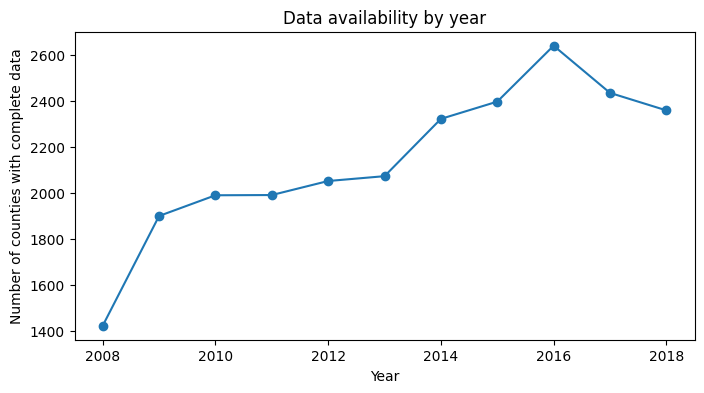

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(valid_counts_by_year["study_year"], valid_counts_by_year["n_counties"], marker="o")
plt.xlabel("Year")
plt.ylabel("Number of counties with complete data")
plt.title("Data availability by year")
plt.show()

I want to focus on 2018 because it is the most recent year in the dataset and reflects childcare conditions before the COVID-19 pandemic. Using a pre-pandemic year avoids disruptions caused by temporary shocks and provides a more stable baseline that is closer to current long-term childcare patterns.

In [11]:
features = ["mc_infant", "mc_toddler", "mc_preschool", "mhi_2018"]
df_2018 = df[df["study_year"] == 2018][features].dropna()

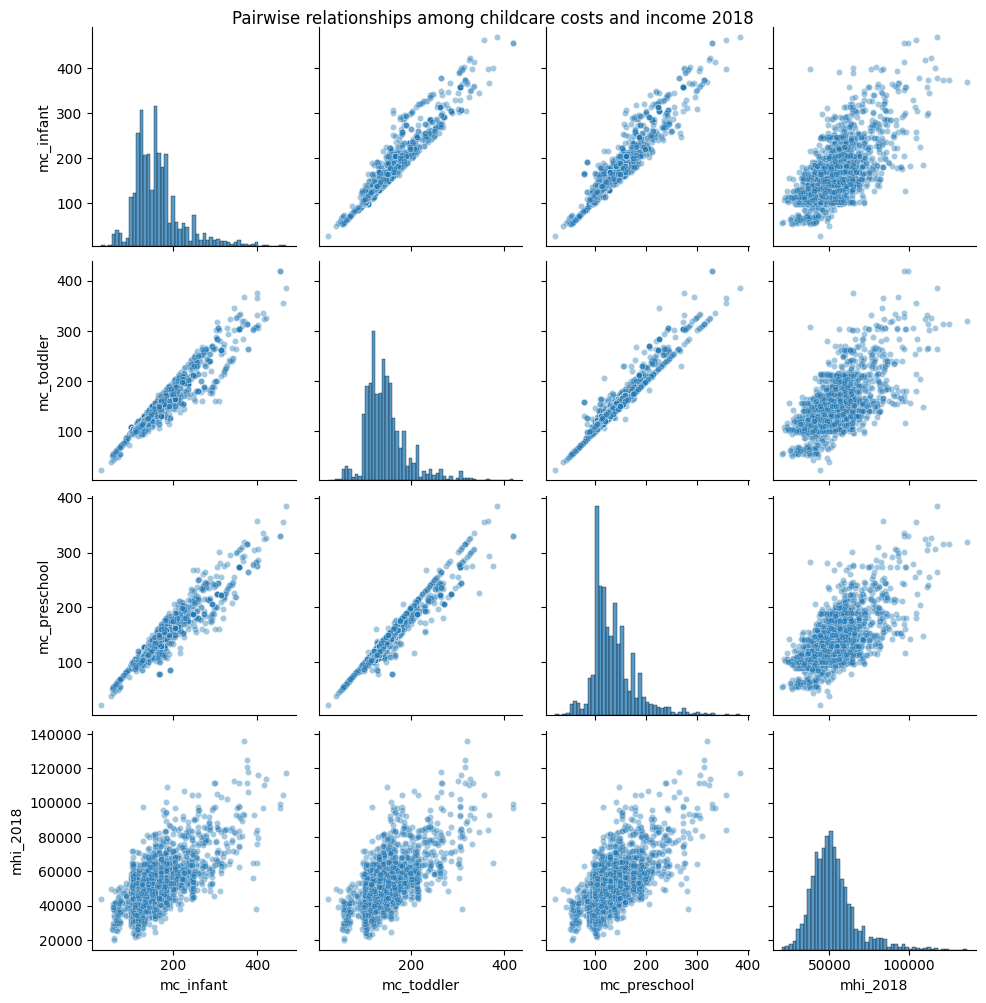

In [12]:
import seaborn as sns

pairplot_vars = ["mc_infant", "mc_toddler", "mc_preschool", "mhi_2018"]

sns.pairplot(
    df_2018[pairplot_vars], diag_kind="hist", plot_kws={"alpha": 0.4, "s": 20}
)

plt.suptitle("Pairwise relationships among childcare costs and income 2018", y=1)
plt.show()

By using pairplots of numeric variables, it shows a significant positive correlation between childcare costs across different age groups, which means that counties with high childcare costs for one age group tend to have higher childcare costs for other age groups as well. In contrast, the relationship between childcare costs and household income was more dispersed, with significant differences in childcare costs even among counties with similar income levels.

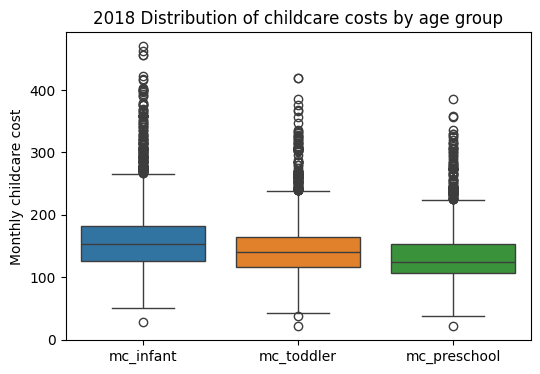

In [13]:
cost_vars = ["mc_infant", "mc_toddler", "mc_preschool"]

plt.figure(figsize=(6,4))
sns.boxplot(data=df_2018[cost_vars])
plt.title("2018 Distribution of childcare costs by age group")
plt.ylabel("Monthly childcare cost")
plt.show()

From this boxplots of childcare costs by age group it shows that infant childcare costs have the highest median and the greatest variability, then come with toddler and preschool costs. All three distributions are right-skewed, with a small number of counties experiencing extremely high childcare costs.

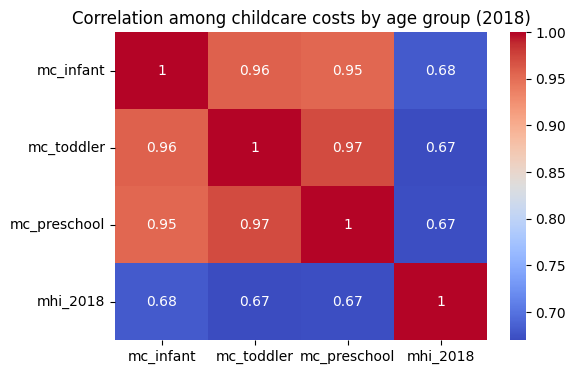

In [14]:
corr = df_2018.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation among childcare costs by age group (2018)")
plt.show()

I also examined the correlation structure among infant, toddler, and preschool childcare costs in 2018. The three cost measures are strongly positively correlated. It shows that counties facing high childcare costs for one age group tend to face high costs across other age groups as well. Also, this correlations are not perfect, but age-specific cost differences may still contribute meaningful variation when identifying childcare burden archetypes.

In [15]:
df_2018["income_q"] = pd.qcut(df_2018["mhi_2018"], 4, labels=False)

df_2018.groupby("income_q")["mc_infant"].describe()

,count,mean,std,min,25%,50%,75%,max
income_q,,,,,,,,
0,590.0,122.785153,31.541849,53.58,108.2900,124.525,137.7175,397.70
1,590.0,148.071390,34.964667,27.73,126.9375,146.490,167.6500,312.00
2,590.0,164.434288,39.810891,72.10,134.6225,166.255,183.0875,390.82
3,590.0,214.277475,72.576838,99.37,158.9300,198.045,256.0200,470.00


To gain a deeper understanding of childcare burden, I also examined cost differences across different income quartiles. Even in counties with similar income levels, significant differences in childcare costs were observed, suggesting that income alone cannot fully explain childcare burden.

In [16]:
df_2018[features].describe().loc[["mean", "std", "min", "max"]]

,mc_infant,mc_toddler,mc_preschool,mhi_2018
mean,162.392076,145.958242,135.920983,52184.898729
std,58.159559,47.515914,42.977066,14026.094771
min,27.730000,21.540000,21.540000,20188.000000
max,470.000000,419.000000,385.000000,136268.000000


In [17]:
df_2018[["mc_infant", "mc_toddler", "mc_preschool", "mhi_2018"]].skew()

,0
mc_infant,1.508812
mc_toddler,1.482401
mc_preschool,1.437743
mhi_2018,1.338537


I did a additional preprocessing checks, it shows that there is a significant scale difference between the childcare cost variable and the median household income, and that childcare costs exhibited a right-skewed distribution. These characteristics suggest that distance-based unsupervised methods may be sensitive to scale and extreme values.

## **3. Analysis 1：Clustering**

### **Hierarchical Clustering**

In [18]:
features = ["mc_infant", "mc_toddler", "mc_preschool", "mhi_2018"]
df_2018 = df[df["study_year"] == 2018][features].dropna()
df_2018.shape

(2360, 4)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df_2018),
    columns=features,
    index=df_2018.index
)

df_normalized.describe()

,mc_infant,mc_toddler,mc_preschool,mhi_2018
count,2.360000e+03,2.360000e+03,2.360000e+03,2.360000e+03
mean,2.408619e-16,-3.462390e-16,-2.468835e-16,-1.475279e-16
std,1.000212e+00,1.000212e+00,1.000212e+00,1.000212e+00
min,-2.315881e+00,-2.619009e+00,-2.662006e+00,-2.281724e+00
25%,-6.190247e-01,-6.265701e-01,-6.975193e-01,-6.588154e-01
50%,-1.512037e-01,-1.254212e-01,-2.541657e-01,-1.314542e-01
75%,3.422420e-01,4.008298e-01,4.067919e-01,4.243064e-01
max,5.290156e+00,5.747540e+00,5.796855e+00,5.996033e+00


In [20]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(df_normalized, method="ward")

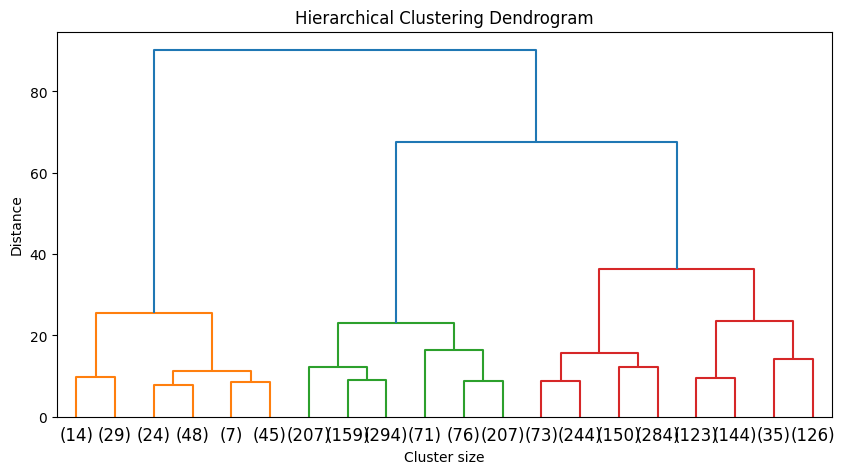

In [21]:
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster size")
plt.ylabel("Distance")
plt.show()

My want to using hierarchical to look at the structure first and then decide on K. The dendrogram shows a large jump at higher distances, which means that merging large groups would combine counties that are very different from each other. So I decided K should not be too small.

In [22]:
from scipy.cluster.hierarchy import fcluster

n_clusters = 3
cluster_labels_hc = fcluster(Z, n_clusters, criterion="maxclust")

df_hc = df_normalized.copy()
df_hc["cluster"] = cluster_labels_hc
df_hc["cluster"].value_counts()

,count
cluster,
3,1179
2,1014
1,167


I first used hierarchical clustering. It shows that most counties were grouped into two larger groups, while only a small subset formed a single smaller group. This result suggests that most counties are relatively similar in terms of childcare costs and income, thus naturally clustering into two main groups. At the same time, a distinctly different smaller group also exists.

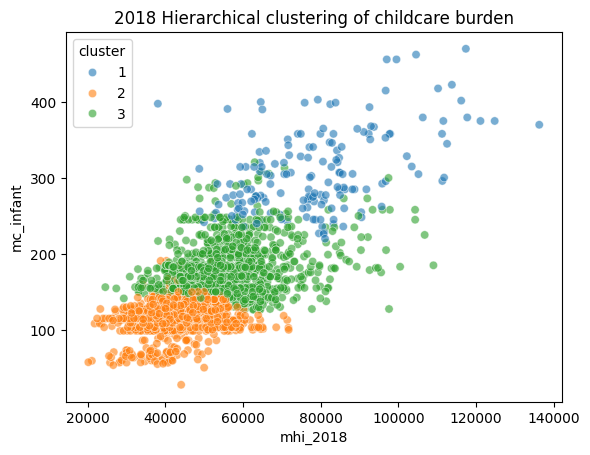

In [23]:
df_plot = df_2018.copy()
df_plot["cluster"] = cluster_labels_hc

sns.scatterplot(
    data=df_plot, x="mhi_2018", y="mc_infant", hue="cluster", palette="tab10", alpha=0.6
)
plt.title("2018 Hierarchical clustering of childcare burden")
plt.show()

In [24]:
n_clusters = 4
cluster_labels_hc_4 = fcluster(Z, n_clusters, criterion="maxclust")

df_hc_4 = df_normalized.copy()
df_hc_4["cluster"] = cluster_labels_hc_4
df_hc_4["cluster"].value_counts()

,count
cluster,
2,1014
3,751
4,428
1,167


In [25]:
n_clusters = 5
cluster_labels_hc_5 = fcluster(Z, n_clusters, criterion="maxclust")

df_hc_5 = df_normalized.copy()
df_hc_5["cluster"] = cluster_labels_hc_5
df_hc_5["cluster"].value_counts()

,count
cluster,
3,1014
4,751
5,428
2,124
1,43


In [26]:
pd.DataFrame({
    "k=4": df_hc["cluster"].value_counts().sort_index(),
    "k=3": df_hc_4["cluster"].value_counts().sort_index(),
    "k=5": df_hc_5["cluster"].value_counts().sort_index()
})

,k=4,k=3,k=5
cluster,,,
1,167.0,167.0,43
2,1014.0,1014.0,124
3,1179.0,751.0,1014
4,NaN,428.0,751
5,NaN,NaN,428


### **KMeans Clustering**

In [27]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

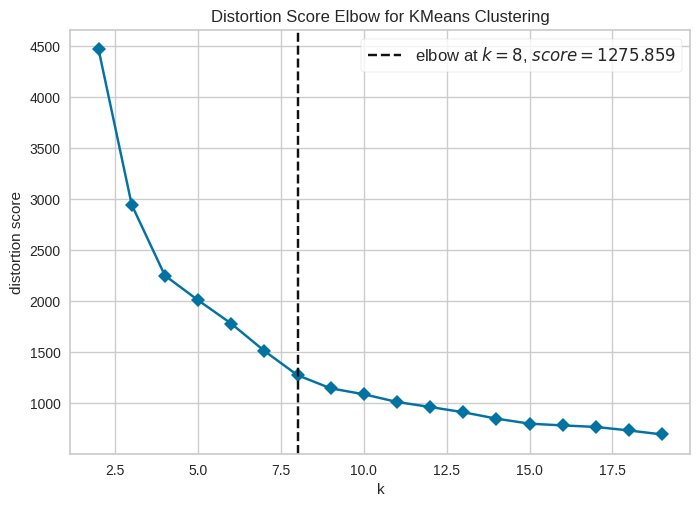

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [28]:
clustering = KMeans(random_state=42)
visualizer = KElbowVisualizer(
    clustering,
    k=(2, 20),
    metric='distortion',
    timings=False,
    random_state=42
)
visualizer.fit(df_normalized)
visualizer.show()

In [29]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels_km = kmeans.fit_predict(df_normalized)

df_km = df_normalized.copy()
df_km["cluster"] = cluster_labels_km
df_km["cluster"].value_counts()

,count
cluster,
0,1128
1,1030
2,202


Then I used K-means clustering which have a similar to the results of hierarchical clustering, most counties were grouped into two larger groups, with one significantly smaller group. This shows that this grouping pattern is not a random result of any particular algorithm, but it is the actual structure that exists within the data.

In [30]:
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)

cluster_centers

,mc_infant,mc_toddler,mc_preschool,mhi_2018
0,121.401569,112.413254,105.056835,43774.190603
1,180.473078,161.012447,150.500660,56225.533010
2,299.094356,256.517228,233.929356,78548.391089


From this I found the first group comprises low-income counties with relatively low childcare costs, but who may still face affordability issues due to limited income. The second group represents a baseline of middle-cost, middle-income levels. The third group includes high-income counties with significantly higher childcare costs, indicating that high income does not fully offset childcare burden.

In [31]:
n_clusters = 8
cluster_labels_hc = fcluster(Z, n_clusters, criterion="maxclust")

df_hc = df_normalized.copy()
df_hc["cluster"] = cluster_labels_hc
df_hc["cluster"].value_counts()

,count
cluster,
6,751
3,660
5,283
7,267
8,161
2,124
4,71
1,43


In [32]:
n_clusters = 4
cluster_labels_hc = fcluster(Z, n_clusters, criterion="maxclust")

df_hc = df_normalized.copy()
df_hc["cluster"] = cluster_labels_hc
df_hc["cluster"].value_counts()

,count
cluster,
2,1014
3,751
4,428
1,167


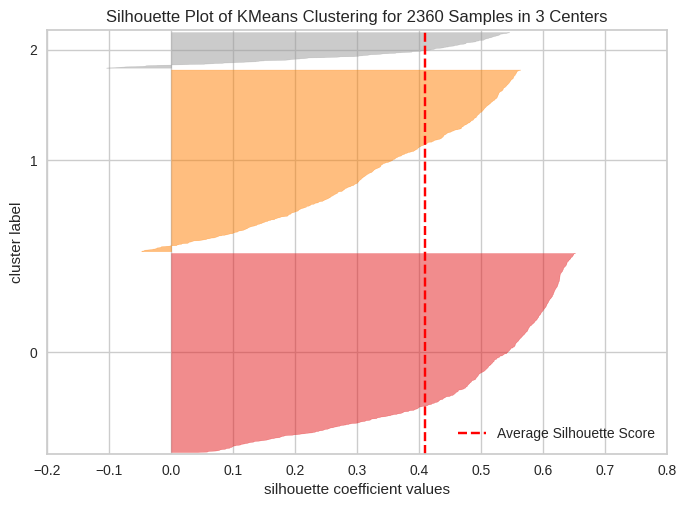

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 2360 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [33]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
visualizer_3 = SilhouetteVisualizer(kmeans_3, timings=False)

visualizer_3.fit(df_normalized)
visualizer_3.show()

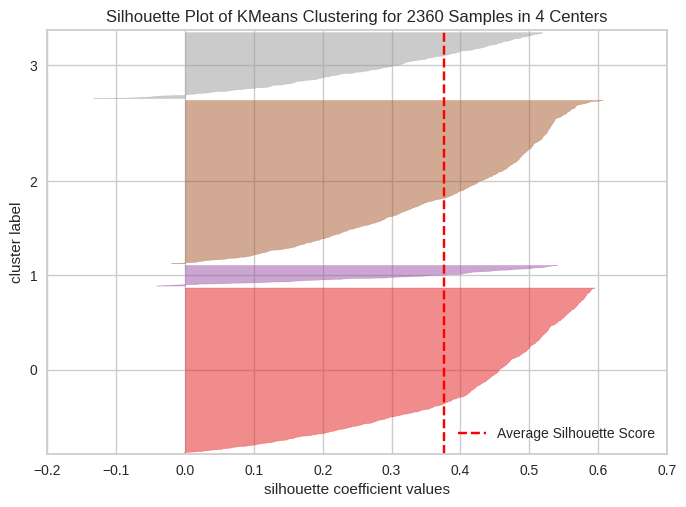

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 2360 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [34]:
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
visualizer_4 = SilhouetteVisualizer(kmeans_4, timings=False)

visualizer_4.fit(df_normalized)
visualizer_4.show()

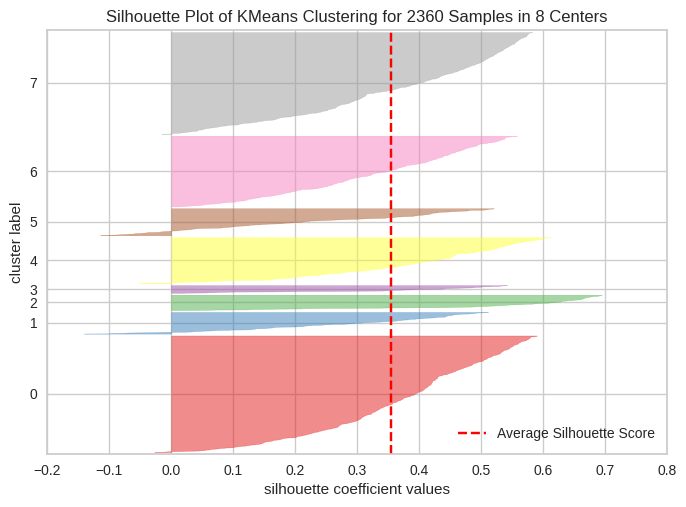

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 2360 Samples in 8 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [35]:
kmeans_6 = KMeans(n_clusters=8, random_state=42, n_init=10)
visualizer_6 = SilhouetteVisualizer(kmeans_6, timings=False)

visualizer_6.fit(df_normalized)
visualizer_6.show()

I also did comparing with different values of K. When K=2, the clustering is overly simplistic and merges most counties into a single group, masking important differences. When K=4 and K=8, I think the results introduce additional subgroups but increase complexity without substantially improving interpretability.

Comparing silhouette plots across different values of K shows that increasing the number of clusters does not consistently improve clustering quality.

K=3 provides a reasonable balance: most counties have positive silhouette scores, and the average silhouette is relatively high. Increasing K to 4 or 8 creates smaller and less stable clusters without improving overall separation.

These results suggest that childcare burden varies gradually across counties rather than forming many sharply separated groups. This supports the interpretation that counties lie along a burden continuum, with one smaller group of more extreme cases.

Conclusion: By using cluster analysis I found out that while counties in the United States do form a few distinct childcare burden groups, these groups are not defined only by income.

If childcare costs for infants, toddlers, and preschoolers are considered together, counties categorize themselves into low-burden, medium-burden, and high-burden types. These clusters shows consistent cost differences across age groups, not just a particular type of childcare service. Also, counties with similar income levels may appear in different clusters, meaning their childcare burdens relative to their incomes are quite different.


### **3.3 Random Seed Stability**


In [65]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

X = df_normalized.values

In [67]:
n_runs = 20
sil_scores = []
inertias = []
cluster_sizes = []

for seed in range(n_runs):
    km = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels = km.fit_predict(X)

    sil_scores.append(silhouette_score(X, labels))
    inertias.append(km.inertia_)
    cluster_sizes.append(np.bincount(labels))

In this step, because KMeans may initialize different centroids each time. So I want to run it for 20 times and changing the seed each time, to see if the results change.

I will also record three things each time:

silhouette (clustering quality)

inertia (the compactness within clusters, lower is better)

number of people in each cluster (to check if the cluster size is stable)

In [68]:
print("Silhouette Mean:", np.mean(sil_scores))
print("Silhouette Min:", np.min(sil_scores))
print("Silhouette Max:", np.max(sil_scores))

print("Inertia Range:", min(inertias), "to", max(inertias))

Silhouette Mean: 0.4091450896823785
Silhouette Min: 0.4089029743797962
Silhouette Max: 0.4096872884291901
Inertia Range: 2946.5620098093714 to 2946.6529210291255


In [64]:
#check cluster size
for i, sizes in enumerate(cluster_sizes[:5]):
    print(f"Run {i} cluster sizes:", sizes)

Run 0 cluster sizes: [ 198 1140 1022]
Run 1 cluster sizes: [ 202 1128 1030]
Run 2 cluster sizes: [1030 1128  202]
Run 3 cluster sizes: [1145  196 1019]
Run 4 cluster sizes: [1128 1030  202]


To evaluate robustness to initialization, I ran KMeans (k=3) with 20 different random seeds. Based on the silhouette score, it shows negligible variation (0.4089–0.4097), and inertia values ​​are nearly identical across runs. Although cluster label ordering changes, the size distribution consistently reveals one smaller cluster and two larger clusters. This means that the three-cluster solution is highly stable and not driven by random initialization.

### **3.4 Sensitivity to Feature Representation**

In [72]:
df_log = df_2018.copy()

In [73]:
# Convert the variable to log
df_log["log_mhi"] = np.log(df_log["mhi_2018"])
df_log["log_infant"] = np.log(df_log["mc_infant"])
df_log["log_toddler"] = np.log(df_log["mc_toddler"])
df_log["log_preschool"] = np.log(df_log["mc_preschool"])

In [74]:
from sklearn.preprocessing import StandardScaler

X_log = StandardScaler().fit_transform( df_log[["log_infant", "log_toddler", "log_preschool", "log_mhi"]])

In [75]:
km_raw = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)
km_log = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_log)

In [79]:
print("ARI raw vs log:", adjusted_rand_score(km_raw, km_log))

ARI raw vs log: 0.5372597916871298


I used a log transformation on income and childcare cost variables to reduce skewness and limit the effect of very high values. Since KMeans is based on distance, counties with extremely high income or childcare costs can strongly affect how clusters are formed. By comparing the clustering results from the original standardized data and the log-transformed data, I wanted to see whether the group structure depends on how the data are represented. The Adjusted Rand Index (ARI) between the two results is about 0.54, which shows moderate similarity. This means the overall childcare burden pattern still exists, but the exact cluster boundaries change. This suggests that counties are spread along a gradual affordability scale rather than forming completely separate and naturally distinct groups.

## **4. Analysis 2: Principal Component Analysis**

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_2018)

In [37]:
pca = PCA()
X_pca = pca.fit_transform(df_normalized)

pca.explained_variance_ratio_

array([0.86813612, 0.11243531, 0.01223489, 0.00719369])

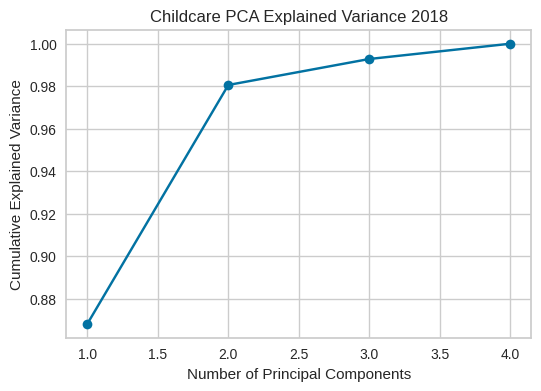

In [38]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_.cumsum(),
         marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Childcare PCA Explained Variance 2018")
plt.show()

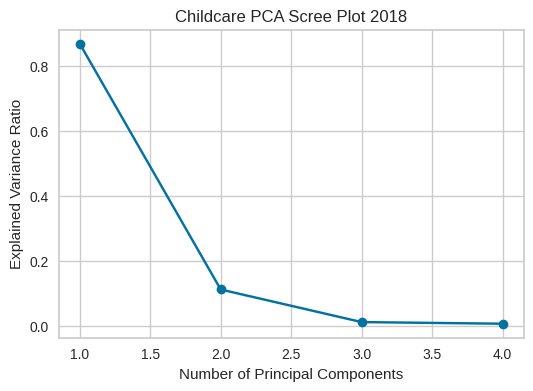

In [87]:
plt.figure(figsize=(6,4))
plt.plot( range(1, len(pca.explained_variance_ratio_) + 1),
          pca.explained_variance_ratio_,
          marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Childcare PCA Scree Plot 2018")
plt.show()

In [39]:
np.cumsum(pca.explained_variance_ratio_)

array([0.86813612, 0.98057143, 0.99280631, 1.        ])

The PC1 shows there is approximately 86.8% of the total variation. The PC2 explains approximately 11.2%. Other principal components contribute very little, almost negligible.

In [40]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=df_normalized.columns
)

loadings

,PC1,PC2,PC3,PC4
mc_infant,0.521445,-0.225582,0.815994,-0.106596
mc_toddler,0.522739,-0.259217,-0.307516,0.751654
mc_preschool,0.522239,-0.254054,-0.488984,-0.650859
mhi_2018,0.426738,0.904088,-0.021976,0.006020


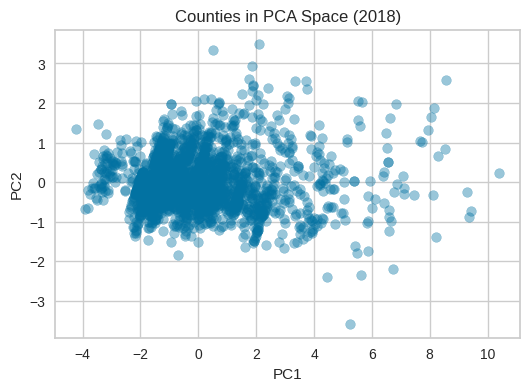

In [41]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])

plt.figure(figsize=(6,4))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Counties in PCA Space (2018)")
plt.show()

The PCA loadings show that childcare costs across all age groups move together and dominate the first principal component. This explains why clustering primarily separates counties by overall childcare burden level rather than by age-specific cost differences. Income plays a secondary role, mainly distinguishing counties with similar cost levels but different income capacity.

Conclusion: By using PCA, it helps me identify the existence of these clusters by revealing the underlying structure of the data. The first principal component reflects the overall intensity of childcare costs across all age groups, which shows us that costs for infants, toddlers, and preschool children tend to rise simultaneously. The second principal component is closely related to household income, distinguishing counties with similar costs but different income levels.

Overall, this tells me that childcare burden is multidimensional: costs may be similar in two counties, but the burden can vary significantly due to differences in income.

In [82]:
loadings = pca.components_[0]
for feature, loading in zip(df_2018.columns, loadings):
    print(feature, ":", round(loading, 3))

mc_infant : 0.521
mc_toddler : 0.523
mc_preschool : 0.522
mhi_2018 : 0.427


This could help me gets the weights for PC1. It prints how much each variable contributes to PC1.

The PCA loadings show that infant, toddler, and preschool childcare costs all have very similar and strong positive weights in PC1, while income also has a positive but slightly smaller weight. This suggests that PC1 represents an overall economic level or childcare price level. Counties with high PC1 values tend to have higher childcare costs and higher income, while counties with low PC1 values tend to have lower costs and lower income.

In [88]:
df_pca = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])
df_pca["cluster"] = km_raw

df_pca.groupby("cluster")["PC1"].mean()

,PC1
cluster,
0,-1.367781
1,0.627960
2,4.435933


This step takes first two principal components and adds original cluster labels. It shows how clusters are positioned in PCA space. Then it calculates the average PC1 value for each cluster. This shows clusters are ordered along PC1.

When I examined the cluster means along PC1, I found that the three clusters are clearly separated along this single principal component. One cluster has low PC1 values, one has medium values, and one has very high values. This shows that the clusters are mainly divided along a continuous affordability gradient rather than being separated across multiple independent directions.

In [89]:
pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X)

labels_pca = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_pca2)

from sklearn.metrics import adjusted_rand_score
print("ARI raw vs PCA-space clustering:",
      adjusted_rand_score(km_raw, labels_pca))

ARI raw vs PCA-space clustering: 0.9828973804183915


Then I reduces data to 2 dimensions, runs KMeans again using only PC1 and PC2. Last, I compares: original clustering (4 variables) and PCA-based clustering (2 variables)

From the Adjusted Rand Index between clustering in the original feature space and clustering in PCA space is about 0.98, which shows that they are almost perfect agreement. This means that reducing the data to two principal components does not change the clustering structure. It shows that the clusters are very stable and are strongly driven by the dominant PC1 dimension.

## **5. Findings & Interpretation**

The results show that income and childcare costs move together. High-income counties often have high childcare costs. This means higher income does not always mean lower burden. Families in high-income areas may still face strong childcare pressure because costs are also high. Therefore, policymakers should look at both income and cost together when measuring affordability, instead of focusing on income alone.
